In [ ]:
# Predictive maintenance preprocessing, specifically C-MAPSS
# you are taking sensor data and condesing them to single "Health index"

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from scipy.stats import gaussian_kde


print("Loading data")
data_train = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None)
data_test = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None)
true_rul = pd.read_csv('RUL_FD001.txt', header=None, names=['True_RUL'])

columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32']

data_train = data_train.iloc[:, :26]
data_test = data_test.iloc[:, :26]
data_train.columns = columns
data_test.columns = columns


Loading data.......


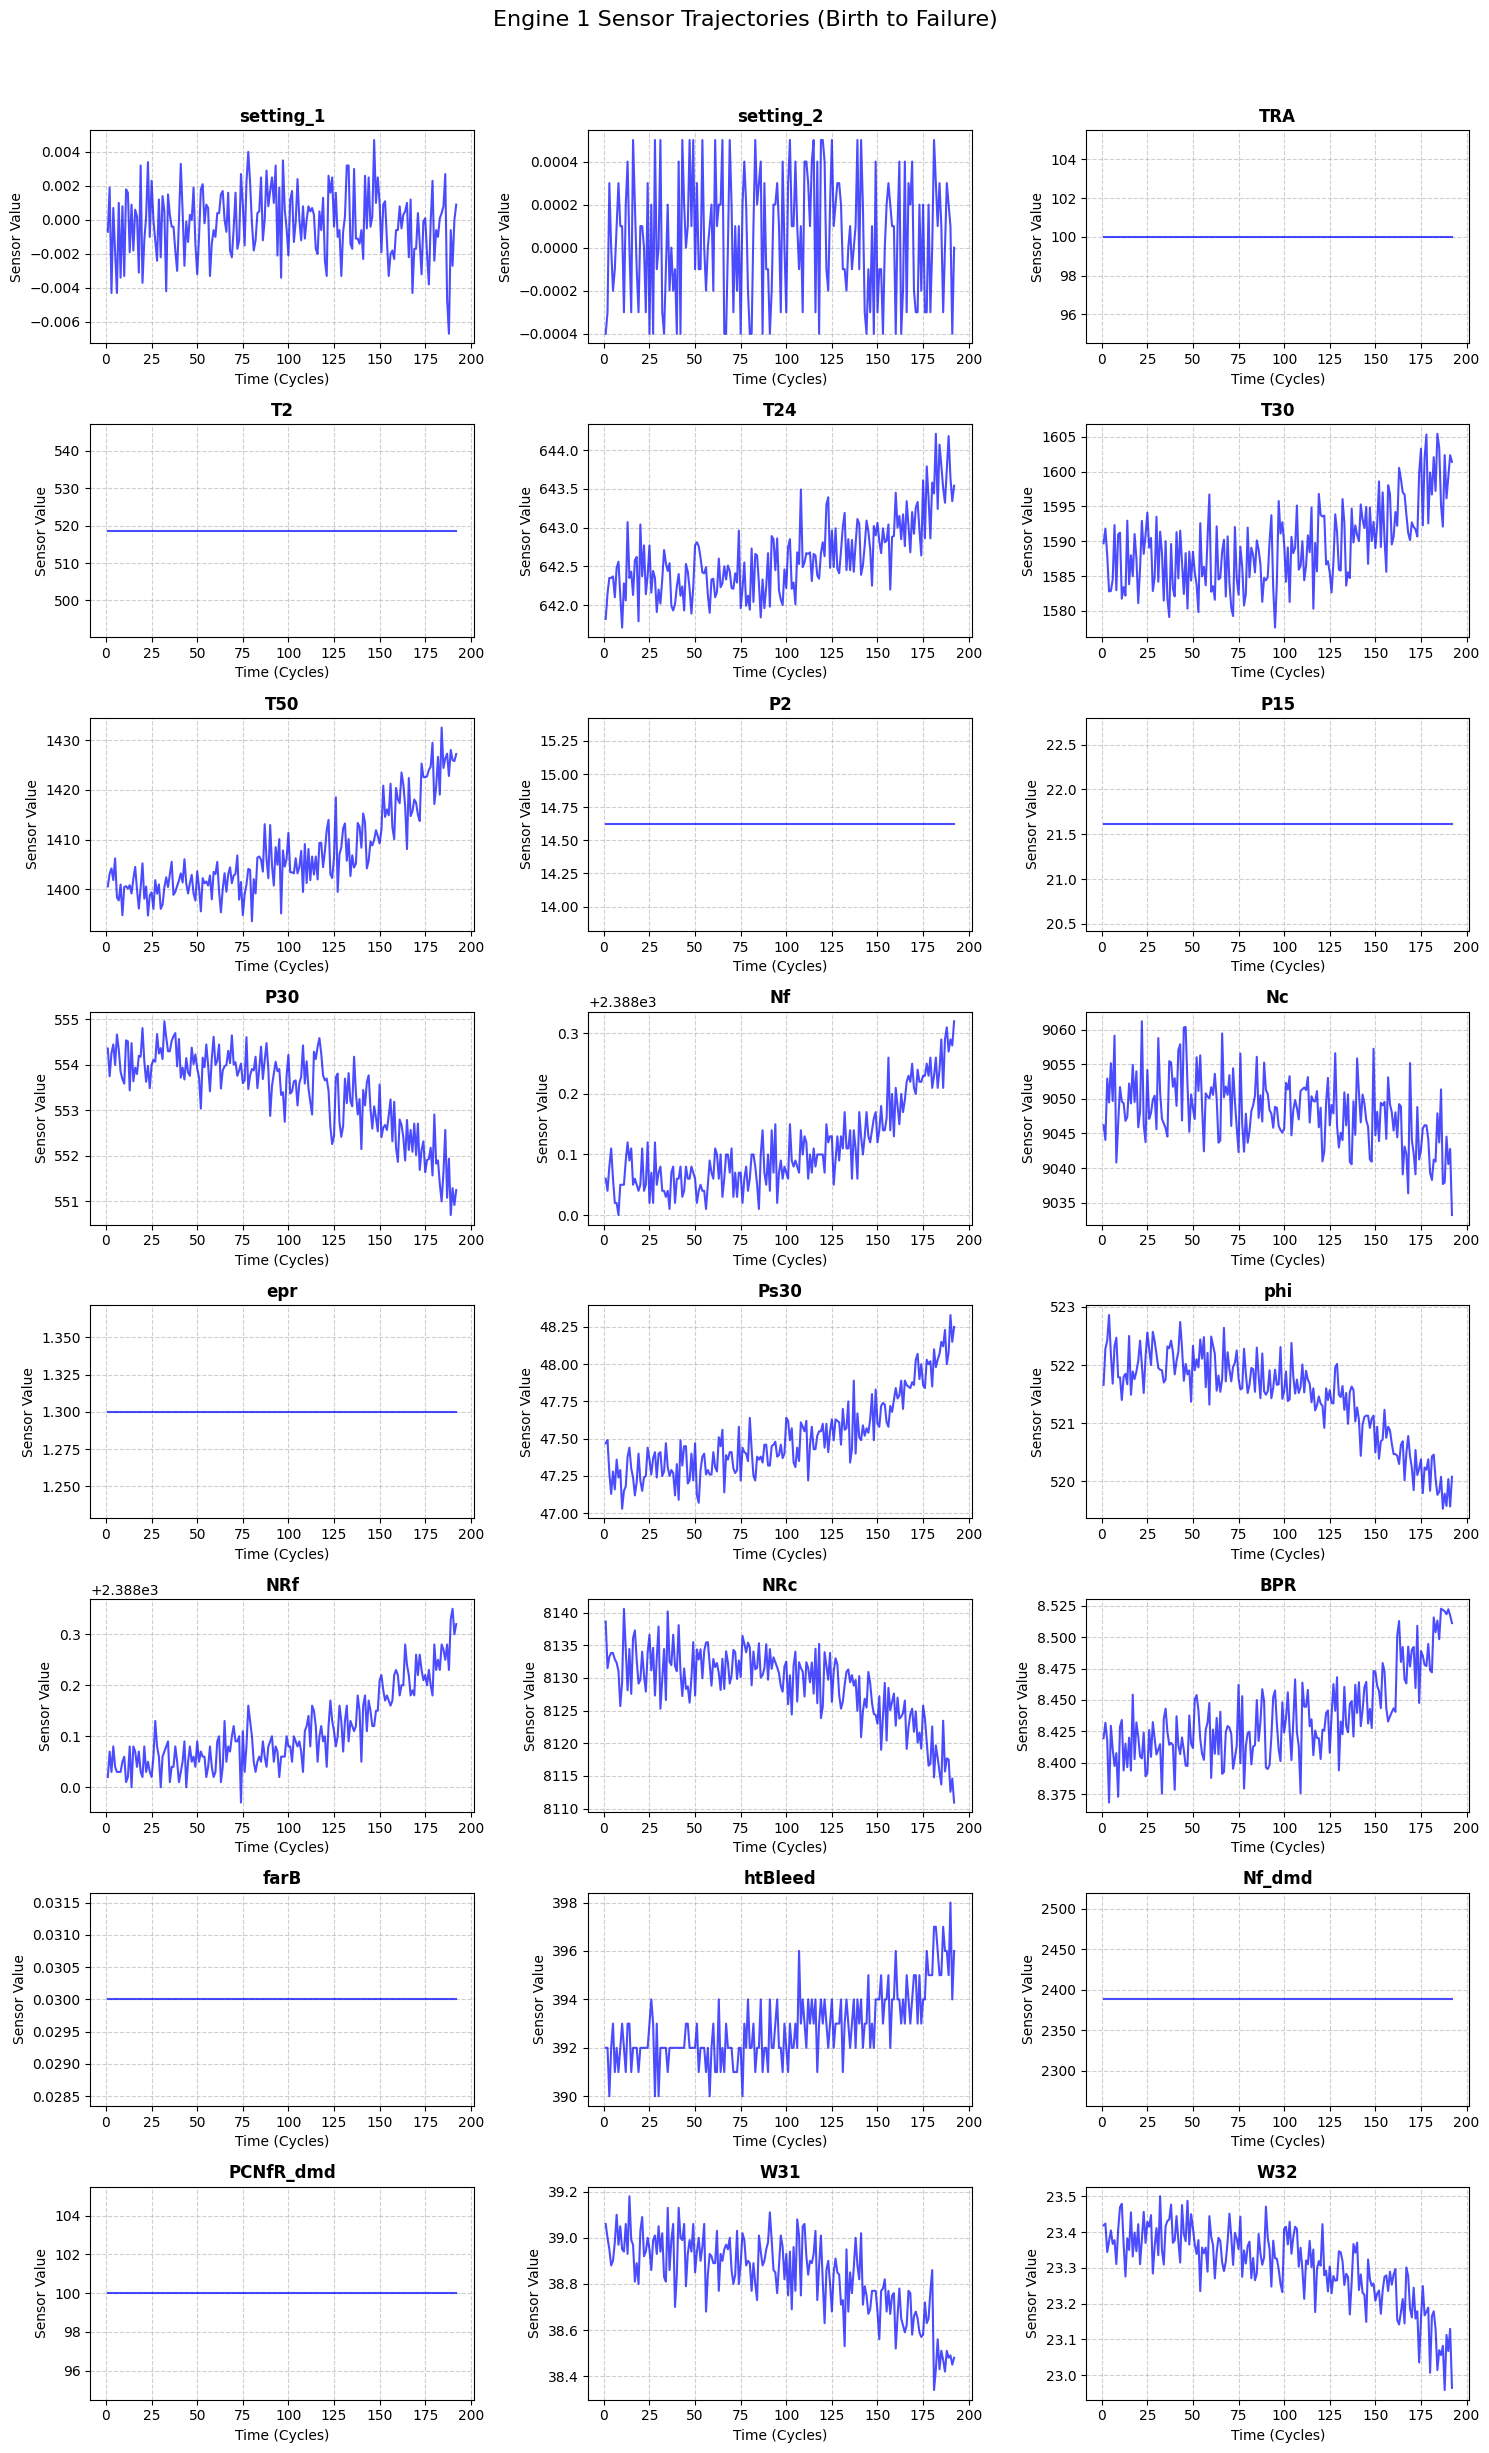

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Let's isolate just Engine 1 from birth to failure
engine_1 = data_train[data_train['unit_number'] == 1]

# List of all 24 columns (3 operational settings + 21 sensors) using their physical names
sensor_columns = ['setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
                  'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32']

# Set up a grid of plots: 8 rows by 3 columns to fit all 24 variables
fig, axes = plt.subplots(8, 3, figsize=(15, 24))
fig.suptitle('Engine 1 Sensor Trajectories (Birth to Failure)', fontsize=16, y=1.02)

# Handle the time column name dynamically to prevent KeyErrors
time_col = 'time_in_cycles'

# Loop through all sensors and plot them one by one
for i, sensor in enumerate(sensor_columns):
    row = i // 3
    col = i % 3
    ax = axes[row, col]

    # Plot the sensor data
    ax.plot(engine_1[time_col], engine_1[sensor], color='blue', alpha=0.7)

    # Set titles and labels
    ax.set_title(sensor, fontweight='bold')
    ax.set_xlabel('Time (Cycles)')
    ax.set_ylabel('Sensor Value')

    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Drop constant columns and operational settings
constant_columns = ['TRA', 'T2', 'P2', 'P15', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
data_train.drop(columns=constant_columns, inplace=True)
data_test.drop(columns=constant_columns, inplace=True)
data_train.drop(columns=['setting_1', 'setting_2'], inplace=True, errors='ignore')
data_test.drop(columns=['setting_1', 'setting_2'], inplace=True, errors='ignore')

sensor_cols = data_train.columns.drop(['unit_number', 'time_in_cycles'])

print(f"Using {len(sensor_cols)} sensors for PCA")
# Initializes a tool that shifts data so its mean is $0$ and standard deviation is $1$.
scaler = StandardScaler()
train_scaled = scaler.fit_transform(data_train[sensor_cols])
test_scaled = scaler.transform(data_test[sensor_cols])

# Take all these different sensor signals and find the one single 'line'
# that explains the most variance.


pca = PCA(n_components=1)
data_train['Health_Index'] = pca.fit_transform(train_scaled)
data_test['Health_Index'] = pca.transform(test_scaled)

def smooth_trajectory_gaussian(df, sigma=3): # strength of smoothening
    smoothed_df = df.copy()
    smoothed_df['Smoothed_Health'] = 0.0
    for unit in df['unit_number'].unique():
        idx = df['unit_number'] == unit
        # This is the math engine. It looks at the Health_Index
        # and applies a weighted moving average.
        # gaussian_filter1d, it performs a mathematical operation called convolution.
        # $$(f * g)[n] = \sum_{m=-M}^{M} f[n-m]g[m]$$
        # Smoothing Kernel (Gaussian):
        # Uses a bell-curve shape. This removes noise and "jitters."

        smoothed = gaussian_filter1d(df.loc[idx, 'Health_Index'], sigma=sigma)
        smoothed_df.loc[idx, 'Smoothed_Health'] = smoothed
    return smoothed_df

train_processed = smooth_trajectory_gaussian(data_train, sigma=3)
test_processed = smooth_trajectory_gaussian(data_test, sigma=3)


# trajectory Matching (or "Nearest neighbour")
# Engines are individual. Some are "born" stronger than others.
# By matching the shape of the degradation curve rather than
# just looking at a single point in time, you capture the unique "personality"
# of how that specific engine is wearing down.

def get_rul_predictions_for_unit(test_traj, train_processed_df, gamma=0.65, rul_cap=125):
    predictions = []
    weights = []
    test_len = len(test_traj)
    test_slope = np.gradient(test_traj) # This calculates the slope (velocity) of the health decline.

    for train_unit in train_processed_df['unit_number'].unique():
        train_traj = train_processed_df[train_processed_df['unit_number'] == train_unit]['Smoothed_Health'].values
        train_len = len(train_traj)

        if test_len > train_len:
            continue

        train_slope = np.gradient(train_traj)
        min_dist = float('inf')
        best_rul = 0

        for lag in range(train_len - test_len + 1):
            window_traj = train_traj[lag : lag + test_len]
            window_slope = train_slope[lag : lag + test_len]

            dist_traj = np.linalg.norm(test_traj - window_traj) # It calculates the Euclidean Distance.
            dist_slope = np.linalg.norm(test_slope - window_slope)
            dist = dist_traj + dist_slope

            if dist < min_dist:
                min_dist = dist
                raw_rul = train_len - (lag + test_len)
                best_rul = min(raw_rul, rul_cap)

        if min_dist == 0:
            min_dist = 1e-5

        predictions.append(best_rul)
        weights.append(np.exp(-gamma * min_dist))

    return predictions, weights

# MODEL AGGREGATION (KDE)
def aggregate_predictions_kde(predictions, weights):
    if not predictions:
        return 0

    predictions_jittered = np.array(predictions) + np.random.normal(0, 0.1, len(predictions))

    try:
        kde = gaussian_kde(predictions_jittered, weights=weights)
        x_grid = np.linspace(0, max(predictions) + 100, 500)
        pdf = kde.evaluate(x_grid)
        predicted_rul = x_grid[np.argmax(pdf)]
    except np.linalg.LinAlgError:
        predicted_rul = np.average(predictions, weights=weights)

    return predicted_rul

# RUN PREDICTIONS
print("Running Restored TSBP Predictions")
final_predictions = []

for test_unit in test_processed['unit_number'].unique():
    test_traj = test_processed[test_processed['unit_number'] == test_unit]['Smoothed_Health'].values
    preds, weights = get_rul_predictions_for_unit(test_traj, train_processed, gamma=0.5, rul_cap=115)
    predicted_rul = aggregate_predictions_kde(preds, weights)
    final_predictions.append(predicted_rul)

results_df = pd.DataFrame({
    'unit_number': test_processed['unit_number'].unique(),
    'Predicted_RUL': np.round(final_predictions)
})

results_df['True_RUL'] = true_rul['True_RUL'].values
results_df['Error'] = results_df['Predicted_RUL'] - results_df['True_RUL']
rmse = np.sqrt(np.mean(results_df['Error']**2))

print(f"\nRoot Mean Squared Error (RMSE): {rmse:.2f}")
print("\nPredictions Complete! First 5 results:")
print(results_df.head())

Using 14 sensors for PCA...
Running Restored TSBP Predictions...

Root Mean Squared Error (RMSE): 19.12

Predictions Complete! First 5 results:
   unit_number  Predicted_RUL  True_RUL  Error
0            1          113.0       112    1.0
1            2          112.0        98   14.0
2            3           52.0        69  -17.0
3            4           54.0        82  -28.0
4            5           58.0        91  -33.0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_detailed_metrics(y_true, y_pred):
    # Standard Regression Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Over-estimation Analysis
    errors = y_pred - y_true
    over_estimates = errors[errors > 0]
    num_over = len(over_estimates)
    total_samples = len(y_true)

    avg_over_est = np.mean(over_estimates) if num_over > 0 else 0
    pct_over_est = (num_over / total_samples) * 100


    print(" Accuracy Metrics ")
    print(f"RMSE: {rmse:.2f} cycles")
    print(f"MAE:  {mae:.2f} cycles")
    print(f"R² Score: {r2:.4f}")

    print("Risk Analysis (Bias) ")
    print(f"Percentage of Over-estimates: {pct_over_est:.2f}%")
    print(f"Average Over-estimate Error:  +{avg_over_est:.2f} cycles")


calculate_detailed_metrics(results_df['True_RUL'], results_df['Predicted_RUL'])

 Accuracy Metrics 
RMSE: 19.12 cycles
MAE:  13.95 cycles
R² Score: 0.7882
Risk Analysis (Bias) 
Percentage of Over-estimates: 51.00%
Average Over-estimate Error:  +11.59 cycles


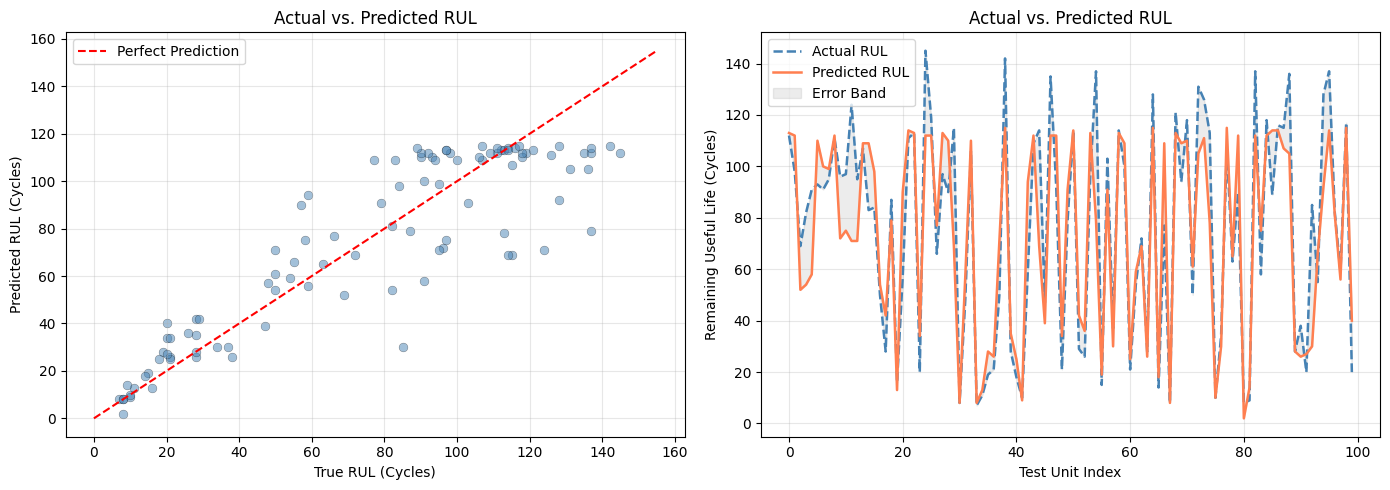

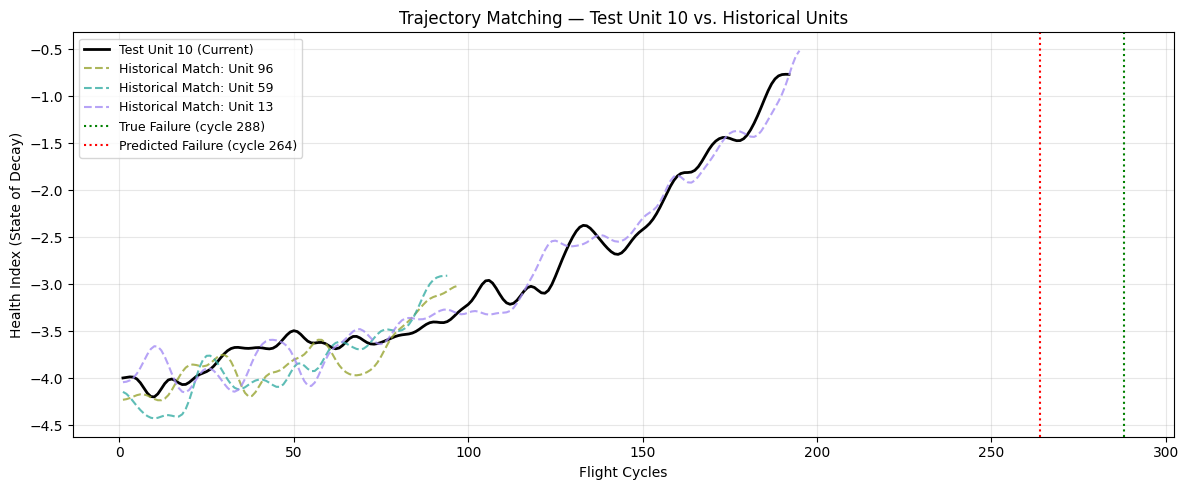

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Actual vs Predicted RUL
def plot_actual_vs_predicted(results_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    ax = axes[0]
    ax.scatter(results_df['True_RUL'], results_df['Predicted_RUL'],
               alpha=0.5, color='steelblue', edgecolors='k', linewidths=0.3, s=40)
    lims = [0, max(results_df['True_RUL'].max(), results_df['Predicted_RUL'].max()) + 10]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlabel('True RUL (Cycles)')
    ax.set_ylabel('Predicted RUL (Cycles)')
    ax.set_title('Actual vs. Predicted RUL')
    ax.legend()
    ax.grid(alpha=0.3)

    # Line graph
    ax2 = axes[1]
    ax2.plot(results_df['True_RUL'].values, label='Actual RUL',
             linestyle='--', color='steelblue', linewidth=1.8)
    ax2.plot(results_df['Predicted_RUL'].values, label='Predicted RUL',
             color='coral', linewidth=1.8)
    ax2.fill_between(range(len(results_df)),
                     results_df['True_RUL'].values,
                     results_df['Predicted_RUL'].values,
                     alpha=0.15, color='grey', label='Error Band')
    ax2.set_xlabel('Test Unit Index')
    ax2.set_ylabel('Remaining Useful Life (Cycles)')
    ax2.set_title('Actual vs. Predicted RUL')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_actual_vs_predicted(results_df)


# Test Unit Trajectory Comparison
def plot_trajectory_comparison(df, results_df, test_unit_id, top_n=3):
    HEALTH_COL = 'Smoothed_Health'
    CYCLE_COL = 'time_in_cycles'

    from scipy.spatial.distance import euclidean

    fig, ax = plt.subplots(figsize=(12, 5))
    palette = sns.color_palette("husl", top_n + 1)

    # Plot test unit
    test_traj_data = df[df['unit_number'] == test_unit_id].sort_values(CYCLE_COL)
    test_traj_values = test_traj_data[HEALTH_COL].values
    test_cycles = test_traj_data[CYCLE_COL].values

    ax.plot(test_cycles, test_traj_values,
            color='black', linewidth=2, label=f'Test Unit {test_unit_id} (Current)')

    # Find closest matches
    candidates = df[df['unit_number'] != test_unit_id]['unit_number'].unique()
    distances = {}
    for uid in candidates:
        traj = df[df['unit_number'] == uid].sort_values(CYCLE_COL)[HEALTH_COL].values
        min_len = min(len(test_traj_values), len(traj))
        distances[uid] = euclidean(test_traj_values[:min_len], traj[:min_len])

    top_matches = sorted(distances, key=distances.get)[:top_n]

    for i, uid in enumerate(top_matches):
        match_traj = df[df['unit_number'] == uid].sort_values(CYCLE_COL)
        ax.plot(match_traj[CYCLE_COL], match_traj[HEALTH_COL],
                color=palette[i+1], linewidth=1.5, linestyle='--',
                alpha=0.8, label=f'Historical Match: Unit {uid}')

    # Mark predicted vs true failure point
    last_cycle = test_cycles.max()
    unit_result = results_df[results_df['unit_number'] == test_unit_id]
    if not unit_result.empty:
        pred_rul = unit_result['Predicted_RUL'].values[0]
        true_rul = unit_result['True_RUL'].values[0]
        ax.axvline(last_cycle + true_rul, color='green', linestyle=':',
                   linewidth=1.5, label=f'True Failure (cycle {int(last_cycle + true_rul)})')
        ax.axvline(last_cycle + pred_rul, color='red', linestyle=':',
                   linewidth=1.5, label=f'Predicted Failure (cycle {int(last_cycle + pred_rul)})')

    ax.set_xlabel('Flight Cycles')
    ax.set_ylabel('Health Index (State of Decay)')
    ax.set_title(f'Trajectory Matching — Test Unit {test_unit_id} vs. Historical Units')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_trajectory_comparison(test_processed, results_df, test_unit_id=10, top_n=3)